# Singular Value Decomposition (SVD)

奇异值描述了矩阵对应的拉伸变换在各个方向的比例，是矩阵的重要特征。

奇异值的分布通常非常不均，在很多的情况下前10%甚至1%的奇异值之和就占了全部奇异值之和的99%以上。

因此我们可以用前个大的奇异值来近似的描述矩阵。


Matplotlib is building the font cache; this may take a moment.


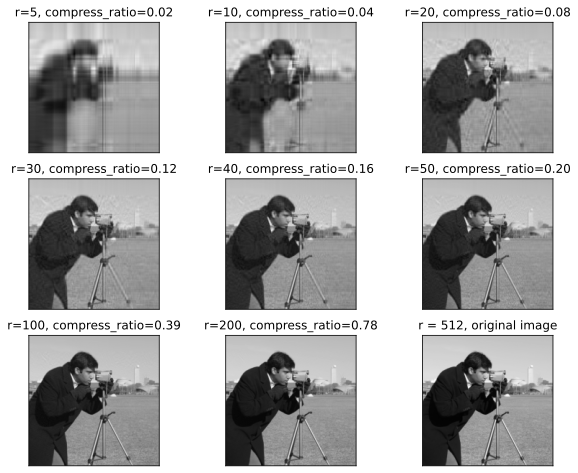

In [1]:
# 下面的范例示范SVD分解用于图片数据压缩。
%matplotlib inline 
%config InlineBackend.figure_format = 'svg'
import numpy as np 
from matplotlib import pyplot as plt
from skimage import data
 
def compressBySVD(img,r):
    u,s,vt = np.linalg.svd(img)
    ur = u[:,0:r]
    sr = s[0:r]
    vtr = vt[0:r,:]
    return (ur,sr,vtr)
 
def rebuildFromSVD(ur,sr,vtr):
    img = ur@np.diag(sr)@vtr
    return(img)
 
 
img = data.camera()/255.0
 
plt.figure(figsize=(10,8)) 
for i,r in enumerate([5,10,20,30,40,50,100,200],start = 1):
    ur,sr,vtr = compressBySVD(img,r)
    compress_ratio = (np.product(ur.shape) + len(sr) + 
                      np.product(vtr.shape))/np.product(img.shape)
    img_rebuild = rebuildFromSVD(ur,sr,vtr)
    ax=plt.subplot(3,3,i)
    ax.imshow(img_rebuild,cmap = "gray")
    ax.set_title("r=%d"%r+", compress_ratio=%.2f"%compress_ratio)
    ax.set_xticks([])
    ax.set_yticks([]) 
 
ax = plt.subplot(3,3,9)
ax.imshow(img,cmap = "gray")
ax.set_title("r = 512, original image")
ax.set_xticks([])
ax.set_yticks([]) 
 
plt.show()

In [3]:
img.shape

(512, 512)

In [4]:
img

array([[0.78431373, 0.78431373, 0.78431373, ..., 0.74117647, 0.74509804,
        0.74509804],
       [0.78431373, 0.78039216, 0.78039216, ..., 0.74509804, 0.74509804,
        0.74509804],
       [0.78039216, 0.78039216, 0.78039216, ..., 0.74509804, 0.74509804,
        0.74509804],
       ...,
       [0.09803922, 0.09803922, 0.10588235, ..., 0.54509804, 0.47843137,
        0.57647059],
       [0.09803922, 0.09803922, 0.10196078, ..., 0.61960784, 0.55294118,
        0.65882353],
       [0.09803922, 0.09803922, 0.10588235, ..., 0.59215686, 0.59607843,
        0.58431373]])